# Sanskrit → English Neural Machine Translation
**Custom Seq2Seq: BiGRU Encoder + Bahdanau Attention + GRU Decoder + Beam Search**

## Install dependencies

In [ ]:
# !pip install torch sentencepiece nltk bert-score pandas numpy matplotlib ipykernel
# I ran this code on A100 server which has CUDA Version: 12.7

## Imports, seed & configuration

In [17]:
import os, time, math, random, io
import numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import sentencepiece as spm
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

class CFG:
    DATA_DIR   = "."
    # 10k training pairs -> smaller vocab trains better (tokens seen more often)
    # and lowers the parameter count (helps the efficiency score).
    SRC_VOCAB  = 4000
    TGT_VOCAB  = 4000
    MAX_LEN    = 80
    EMB        = 256
    HID        = 512
    ENC_LAYERS = 2
    DROPOUT    = 0.4
    BATCH      = 64
    EPOCHS     = 80
    LR         = 1e-3
    CLIP       = 1.0
    TF_RATIO   = 0.5
    LABEL_SMOOTH = 0.1
    PATIENCE   = 12
    BEAM       = 5
    LEN_PENALTY= 0.7
cfg = CFG()
PAD, UNK, BOS, EOS = 0, 1, 2, 3

Device: cuda


## Load & align the parallel data

In [18]:
import glob
def _find(split, lang):
    # matches train_sa_10000.csv, dev_en_1000.csv, or plain train_sa.csv
    hits = sorted(glob.glob(os.path.join(cfg.DATA_DIR, f"{split}_{lang}_*.csv"))) \
         + sorted(glob.glob(os.path.join(cfg.DATA_DIR, f"{split}_{lang}.csv")))
    return hits[0] if hits else None

def load_split(split, need_target=True):
    sa_path = _find(split, "sa")
    sa = pd.read_csv(sa_path).rename(columns={"Sentence_sa":"src"})
    en_path = _find(split, "en")
    if need_target and en_path:
        en = pd.read_csv(en_path).rename(columns={"Sentence_en":"tgt"})
        df = sa.merge(en, on="Source_id", how="inner")[["Source_id","src","tgt"]].dropna()
    else:
        df = sa[["Source_id","src"]].dropna()
    df["src"] = df["src"].astype(str).str.strip()
    if "tgt" in df.columns:
        df["tgt"] = df["tgt"].astype(str).str.strip()
        df = df[(df.src.str.len()>0) & (df.tgt.str.len()>0)]
    return df.reset_index(drop=True)

train_df = load_split("train")
dev_df   = load_split("dev")
test_has_gold = _find("test", "en") is not None
test_df  = load_split("test", need_target=test_has_gold)
print(f"train={len(train_df)} dev={len(dev_df)} test={len(test_df)} test_gold={test_has_gold}")
train_df.head(3)

train=10000 dev=1000 test=1000 test_gold=True


,Source_id,src,tgt
0,1,"""Ctrl, S नुत्वा रक्षन्तु।""","Save it with Ctrl, S."
1,2,गुरुः छात्रान् एकवारं पाठयति ।,Teacher will teach the students only once.
2,3,चित्रचालनमिदं पुनः कर्तुं मया अस्याः राशेः चित...,"To recreate this animation, I have to take two..."


## Subword tokenizers (SentencePiece BPE)
One BPE model per language. Subwords handle Sanskrit sandhi/compounding and keep embedding
tables small. Specials fixed to `pad=0, unk=1, bos=2, eos=3`.

In [19]:
def train_spm(texts, prefix, vocab_size):
    model_file = f"{prefix}.model"
    if not os.path.exists(model_file):
        with io.open(f"{prefix}_corpus.txt","w",encoding="utf-8") as f:
            for t in texts: f.write(t+"\n")
        # Retry with progressively smaller vocab if the corpus can't support the requested size.
        for v in [vocab_size, 6000, 4000, 3000, 2000, 1000]:
            if v > vocab_size: continue
            try:
                spm.SentencePieceTrainer.Train(
                    input=f"{prefix}_corpus.txt", model_prefix=prefix, vocab_size=v,
                    model_type="bpe", character_coverage=1.0,
                    pad_id=PAD, unk_id=UNK, bos_id=BOS, eos_id=EOS,
                    pad_piece="<pad>", unk_piece="<unk>", bos_piece="<s>", eos_piece="</s>")
                print(f"[{prefix}] trained BPE vocab={v}")
                break
            except Exception as e:
                print(f"[{prefix}] vocab={v} failed ({str(e)[:60]}...), retrying smaller")
    sp = spm.SentencePieceProcessor(); sp.Load(model_file); return sp

sp_src = train_spm(train_df.src.tolist(), "spm_sa", cfg.SRC_VOCAB)
sp_tgt = train_spm(train_df.tgt.tolist(), "spm_en", cfg.TGT_VOCAB)
SRC_V, TGT_V = sp_src.get_piece_size(), sp_tgt.get_piece_size()
print("src vocab:", SRC_V, "| tgt vocab:", TGT_V)

src vocab: 4000 | tgt vocab: 4000


## Dataset & batching
Encode to subword ids. Targets get `<s> ... </s>`. Collate pads to the longest in the batch and
returns source lengths for packing / attention masking.

In [20]:
class NMTDataset(Dataset):
    def __init__(self, df, has_tgt=True):
        self.ids = df.Source_id.tolist()
        self.src = [sp_src.encode(s, out_type=int)[:cfg.MAX_LEN] for s in df.src]
        self.tgt = ([[BOS]+sp_tgt.encode(t,out_type=int)[:cfg.MAX_LEN]+[EOS] for t in df.tgt]
                    if has_tgt else None)
    def __len__(self): return len(self.src)
    def __getitem__(self, i):
        s = torch.tensor(self.src[i], dtype=torch.long)
        t = torch.tensor(self.tgt[i], dtype=torch.long) if self.tgt is not None else torch.empty(0,dtype=torch.long)
        return self.ids[i], s, t

def collate(batch):
    ids, srcs, tgts = zip(*batch)
    src_len = torch.tensor([len(s) for s in srcs])
    src_pad = nn.utils.rnn.pad_sequence(srcs, batch_first=True, padding_value=PAD)
    if tgts[0].numel() > 0:
        tgt_pad = nn.utils.rnn.pad_sequence(tgts, batch_first=True, padding_value=PAD)
    else:
        tgt_pad = None
    return list(ids), src_pad, src_len, tgt_pad

train_dl = DataLoader(NMTDataset(train_df), batch_size=cfg.BATCH, shuffle=True, collate_fn=collate)
dev_dl   = DataLoader(NMTDataset(dev_df),   batch_size=cfg.BATCH, shuffle=False, collate_fn=collate)
test_dl  = DataLoader(NMTDataset(test_df, has_tgt=test_has_gold), batch_size=cfg.BATCH,
                      shuffle=False, collate_fn=collate)
print("batches:", len(train_dl), len(dev_dl), len(test_dl))

batches: 157 16 16


## Model Creation
**Encoder** — embedding → 2-layer bidirectional GRU; final forward/backward states are
concatenated and projected to the decoder's initial hidden state.
**Attention** — Bahdanau (additive), masked over source padding.
**Decoder** — single-layer GRU; at each step attends over encoder outputs, concatenates the
context with the input embedding, and predicts the next token from `[gru_out ; context ; emb]`.

In [21]:
class Encoder(nn.Module):
    def __init__(self, vocab):
        super().__init__()
        self.embedding = nn.Embedding(vocab, cfg.EMB, padding_idx=PAD)
        self.rnn = nn.GRU(cfg.EMB, cfg.HID, num_layers=cfg.ENC_LAYERS, bidirectional=True,
                          batch_first=True, dropout=cfg.DROPOUT if cfg.ENC_LAYERS>1 else 0.0)
        self.fc = nn.Linear(cfg.HID*2, cfg.HID)
        self.drop = nn.Dropout(cfg.DROPOUT)
    def forward(self, src, src_len):
        emb = self.drop(self.embedding(src))
        packed = nn.utils.rnn.pack_padded_sequence(emb, src_len.cpu(), batch_first=True, enforce_sorted=False)
        outputs, hidden = self.rnn(packed)               # hidden: (layers*2, B, HID)
        outputs, _ = nn.utils.rnn.pad_packed_sequence(outputs, batch_first=True)  # (B,T,2H)
        fwd, bwd = hidden[-2], hidden[-1]                # last layer's two directions
        dec0 = torch.tanh(self.fc(torch.cat([fwd, bwd], dim=1)))  # (B,HID)
        return outputs, dec0.unsqueeze(0)                # decoder is 1-layer

class Attention(nn.Module):
    def __init__(self):
        super().__init__()
        self.attn = nn.Linear(cfg.HID*2 + cfg.HID, cfg.HID)
        self.v = nn.Linear(cfg.HID, 1, bias=False)
    def forward(self, dec_h, enc_out, mask):
        T = enc_out.size(1)
        dec_rep = dec_h.unsqueeze(1).repeat(1, T, 1)     # (B,T,HID)
        energy = torch.tanh(self.attn(torch.cat([dec_rep, enc_out], dim=2)))
        scores = self.v(energy).squeeze(2).masked_fill(mask==0, -1e9)
        return torch.softmax(scores, dim=1)              # (B,T)

class Decoder(nn.Module):
    def __init__(self, vocab):
        super().__init__()
        self.embedding = nn.Embedding(vocab, cfg.EMB, padding_idx=PAD)
        self.attn = Attention()
        self.rnn = nn.GRU(cfg.EMB + cfg.HID*2, cfg.HID, batch_first=True)
        self.fc_out = nn.Linear(cfg.HID + cfg.HID*2 + cfg.EMB, vocab)
        self.drop = nn.Dropout(cfg.DROPOUT)
    def forward(self, inp, hidden, enc_out, mask):
        emb = self.drop(self.embedding(inp.unsqueeze(1)))          # (B,1,EMB)
        a = self.attn(hidden[-1], enc_out, mask)                   # (B,T)
        context = torch.bmm(a.unsqueeze(1), enc_out)               # (B,1,2H)
        out, hidden = self.rnn(torch.cat([emb, context], dim=2), hidden)  # (B,1,HID)
        pred = self.fc_out(torch.cat([out, context, emb], dim=2).squeeze(1))  # (B,vocab)
        return pred, hidden, a

class Seq2Seq(nn.Module):
    def __init__(self, enc, dec):
        super().__init__(); self.enc, self.dec = enc, dec
    def src_mask(self, src): return (src != PAD).long()
    def forward(self, src, src_len, tgt, tf_ratio):
        enc_out, hidden = self.enc(src, src_len)
        mask = self.src_mask(src)
        B, L = tgt.size(0), tgt.size(1)
        logits = torch.zeros(B, L, self.dec.fc_out.out_features, device=src.device)
        inp = tgt[:, 0]                                            # <s>
        for t in range(1, L):
            pred, hidden, _ = self.dec(inp, hidden, enc_out, mask)
            logits[:, t] = pred
            teacher = random.random() < tf_ratio
            inp = tgt[:, t] if teacher else pred.argmax(1)
        return logits

model = Seq2Seq(Encoder(SRC_V), Decoder(TGT_V)).to(DEVICE)

def count_params(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)
TOTAL_PARAMS = count_params(model)
print(f"Trainable parameters: {TOTAL_PARAMS:,}")

Trainable parameters: 20,378,016


## Decoding (greedy for dev, beam search for final)
Greedy is used for fast per-epoch dev BLEU. Beam search (with length penalty) produces the
final, higher-quality translations used for `submission.csv` and reported metrics.

In [22]:
def ids_to_text(ids):
    ids = [i for i in ids if i not in (PAD, BOS, EOS)]
    return sp_tgt.decode(ids)

@torch.no_grad()
def greedy_decode_batch(src, src_len, max_len=cfg.MAX_LEN):
    model.eval()
    enc_out, hidden = model.enc(src, src_len)
    mask = model.src_mask(src)
    B = src.size(0)
    inp = torch.full((B,), BOS, dtype=torch.long, device=src.device)
    done = torch.zeros(B, dtype=torch.bool, device=src.device)
    outs = [[] for _ in range(B)]
    for _ in range(max_len):
        pred, hidden, _ = model.dec(inp, hidden, enc_out, mask)
        inp = pred.argmax(1)
        for b in range(B):
            if not done[b]:
                if inp[b].item() == EOS: done[b] = True
                else: outs[b].append(inp[b].item())
        if done.all(): break
    return [ids_to_text(o) for o in outs]

@torch.no_grad()
def beam_decode_one(src_ids, beam=cfg.BEAM, max_len=cfg.MAX_LEN, lp=cfg.LEN_PENALTY):
    model.eval()
    src = torch.tensor(src_ids, dtype=torch.long, device=DEVICE).unsqueeze(0)
    src_len = torch.tensor([len(src_ids)])
    enc_out, hidden = model.enc(src, src_len)
    mask = model.src_mask(src)
    # beams: (tokens, logprob, hidden, finished)
    beams = [([BOS], 0.0, hidden, False)]
    for _ in range(max_len):
        if all(f for *_, f in beams): break
        cand = []
        for toks, lp_score, h, fin in beams:
            if fin:
                cand.append((toks, lp_score, h, True)); continue
            inp = torch.tensor([toks[-1]], device=DEVICE)
            pred, h2, _ = model.dec(inp, h, enc_out, mask)
            logp = F.log_softmax(pred, dim=1).squeeze(0)
            toplp, topix = logp.topk(beam)
            for k in range(beam):
                nt = toks + [topix[k].item()]
                cand.append((nt, lp_score + toplp[k].item(), h2, topix[k].item()==EOS))
        # length-normalized ranking
        cand.sort(key=lambda x: x[1] / (len(x[0]) ** lp), reverse=True)
        beams = cand[:beam]
    best = max(beams, key=lambda x: x[1] / (len(x[0]) ** lp))
    return ids_to_text(best[0])

## BLEU / BERTScore helpers
BLEU uses NLTK with default (equal 4-gram) weights per the assignment; smoothing avoids
zero-counts on short sentences. BERTScore reports **F1** with `rescale_with_baseline=True`.

In [23]:
import nltk
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction
_smooth = SmoothingFunction().method1

def compute_bleu(hyps, refs):
    # tokenised by whitespace; refs is a list of single-reference strings
    list_of_refs = [[r.split()] for r in refs]
    hyp_toks = [h.split() for h in hyps]
    corpus = corpus_bleu(list_of_refs, hyp_toks, smoothing_function=_smooth)
    sent = np.mean([sentence_bleu([r.split()], h.split(), smoothing_function=_smooth)
                    for h, r in zip(hyps, refs)]) if hyps else 0.0
    return corpus, sent

def compute_bertscore(hyps, refs):
    from bert_score import score as bscore
    P, R, Fb = bscore(hyps, refs, lang="en", rescale_with_baseline=True,
                      verbose=True, device=str(DEVICE), batch_size=64)
    return Fb.mean().item()

@torch.no_grad()
def dev_bleu():
    hyps, refs = [], []
    for ids, src, src_len, tgt in dev_dl:
        src, src_len = src.to(DEVICE), src_len
        hyps += greedy_decode_batch(src, src_len)
    refs = dev_df.tgt.tolist()
    return compute_bleu(hyps, refs)[0]

## Model Training
Adam + `ReduceLROnPlateau`, gradient clipping, dropout, label smoothing, teacher forcing, and
**early stopping on dev BLEU**. Best checkpoint is restored at the end.

In [24]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD, label_smoothing=cfg.LABEL_SMOOTH)
optimizer = torch.optim.Adam(model.parameters(), lr=cfg.LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=1)

def run_epoch(train=True):
    model.train() if train else model.eval()
    dl = train_dl if train else dev_dl
    total, n = 0.0, 0
    torch.set_grad_enabled(train)
    for ids, src, src_len, tgt in dl:
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)
        logits = model(src, src_len, tgt, cfg.TF_RATIO if train else 0.0)
        loss = criterion(logits[:,1:].reshape(-1, logits.size(-1)), tgt[:,1:].reshape(-1))
        if train:
            optimizer.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), cfg.CLIP); optimizer.step()
        total += loss.item()*src.size(0); n += src.size(0)
    torch.set_grad_enabled(True)
    return total/max(n,1)

hist = {"train_loss":[], "dev_loss":[], "dev_bleu":[]}
best_bleu, bad = -1.0, 0
for ep in range(1, cfg.EPOCHS+1):
    tl = run_epoch(True)
    dl_loss = run_epoch(False)
    dbleu = dev_bleu()
    scheduler.step(dbleu)
    hist["train_loss"].append(tl); hist["dev_loss"].append(dl_loss); hist["dev_bleu"].append(dbleu)
    print(f"ep {ep:02d} | train {tl:.3f} | dev {dl_loss:.3f} | dev BLEU {dbleu:.4f}")
    if dbleu > best_bleu:
        best_bleu, bad = dbleu, 0
        torch.save(model.state_dict(), "best_model.pt")
    else:
        bad += 1
        if bad >= cfg.PATIENCE:
            print("Early stopping."); break
model.load_state_dict(torch.load("best_model.pt", map_location=DEVICE))
print("Best dev BLEU:", best_bleu)

ep 01 | train 6.520 | dev 6.412 | dev BLEU 0.0094
ep 02 | train 5.926 | dev 6.249 | dev BLEU 0.0231
ep 03 | train 5.506 | dev 6.202 | dev BLEU 0.0290
ep 04 | train 5.153 | dev 6.198 | dev BLEU 0.0325
ep 05 | train 4.849 | dev 6.205 | dev BLEU 0.0395
ep 06 | train 4.604 | dev 6.239 | dev BLEU 0.0394
ep 07 | train 4.390 | dev 6.321 | dev BLEU 0.0374
ep 08 | train 4.081 | dev 6.291 | dev BLEU 0.0448
ep 09 | train 3.894 | dev 6.319 | dev BLEU 0.0469
ep 10 | train 3.796 | dev 6.342 | dev BLEU 0.0508
ep 11 | train 3.679 | dev 6.380 | dev BLEU 0.0498
ep 12 | train 3.575 | dev 6.421 | dev BLEU 0.0539
ep 13 | train 3.520 | dev 6.426 | dev BLEU 0.0538
ep 14 | train 3.458 | dev 6.456 | dev BLEU 0.0579
ep 15 | train 3.384 | dev 6.476 | dev BLEU 0.0576
ep 16 | train 3.353 | dev 6.501 | dev BLEU 0.0581
ep 17 | train 3.275 | dev 6.519 | dev BLEU 0.0592
ep 18 | train 3.229 | dev 6.530 | dev BLEU 0.0556
ep 19 | train 3.164 | dev 6.568 | dev BLEU 0.0579
ep 20 | train 3.070 | dev 6.542 | dev BLEU 0.0617


/tmp/ipykernel_4076152/3885306960.py:37: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pt", map_location=DEVICE))


## Model Dev Evaluation

In [31]:
model.eval()
dev_hyps = []
with torch.no_grad():
    for ids, src, src_len, tgt in dev_dl:
        dev_hyps += greedy_decode_batch(src.to(DEVICE), src_len)
dev_refs = dev_df.tgt.tolist()
dc, ds = compute_bleu(dev_hyps, dev_refs)
print(f"Dev corpus BLEU: {dc:.4f} | sentence BLEU: {ds:.4f}")
print(f"Dev BERTScore F1: {compute_bertscore(dev_hyps, dev_refs):.4f}")

Dev corpus BLEU: 0.0678 | sentence BLEU: 0.0773


Loading weights: 100%|██████████| 389/389 [00:00<00:00, 5517.44it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                 | Status  | 
--------------------+---------+-
pooler.dense.bias   | MISSING | 
pooler.dense.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


calculating scores...
computing bert embedding.


100%|██████████| 32/32 [00:03<00:00, 10.41it/s]


computing greedy matching.


100%|██████████| 16/16 [00:00<00:00, 136.07it/s]


done in 3.20 seconds, 312.67 sentences/sec
Dev BERTScore F1: 0.2146


## Training curves

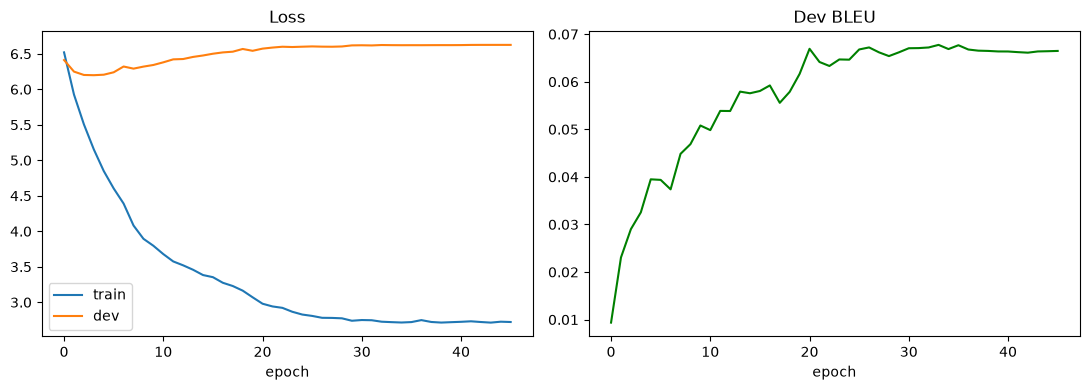

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(11,4))
ax[0].plot(hist["train_loss"], label="train"); ax[0].plot(hist["dev_loss"], label="dev")
ax[0].set_title("Loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(hist["dev_bleu"], color="green"); ax[1].set_title("Dev BLEU"); ax[1].set_xlabel("epoch")
plt.tight_layout(); plt.savefig("training_curves.png", dpi=120); plt.show()

## Evaluate on the test set + inference timing
Beam-search decode the whole test set, measure total inference time, and compute BLEU /
BERTScore if local gold is available.

In [26]:
import os
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"

In [27]:
from tqdm.auto import tqdm
model.eval()
all_ids, test_hyps = [], []
t0 = time.time()
with torch.no_grad():
    for ids, src, src_len, tgt in tqdm(test_dl, desc="translating (greedy)"):
        src = src.to(DEVICE)
        all_ids  += list(ids)
        test_hyps += greedy_decode_batch(src, src_len)
infer_time = time.time() - t0
print(f"Inference time (greedy, batched): {infer_time:.2f}s for {len(test_hyps)} sentences")
print(f"Total parameters: {TOTAL_PARAMS:,}")

if test_has_gold:
    gold = dict(zip(test_df.Source_id, test_df.tgt))
    refs = [gold[i] for i in all_ids]
    c_bleu, s_bleu = compute_bleu(test_hyps, refs)
    print(f"Test corpus BLEU: {c_bleu:.4f} | mean sentence BLEU: {s_bleu:.4f}")
    print(f"Test BERTScore F1 (rescaled): {compute_bertscore(test_hyps, refs):.4f}")

translating (greedy): 100%|██████████| 16/16 [00:02<00:00,  7.44it/s]


Inference time (greedy, batched): 2.15s for 1000 sentences
Total parameters: 20,378,016
Test corpus BLEU: 0.0659 | mean sentence BLEU: 0.0816


Loading weights: 100%|██████████| 389/389 [00:00<00:00, 5794.41it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                 | Status  | 
--------------------+---------+-
pooler.dense.bias   | MISSING | 
pooler.dense.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


calculating scores...
computing bert embedding.


100%|██████████| 31/31 [00:02<00:00, 11.20it/s]


computing greedy matching.


100%|██████████| 16/16 [00:00<00:00, 141.10it/s]


done in 2.89 seconds, 346.11 sentences/sec
Test BERTScore F1 (rescaled): 0.2145


## Translation examples

In [28]:
import textwrap
k = min(8, len(test_df))
for i in range(k):
    print("SRC :", test_df.src.iloc[i])
    if test_has_gold: print("REF :", test_df.tgt.iloc[i])
    print("PRED:", test_hyps[i]); print("-"*70)

SRC : एक्लिप्स् इति प्रोग्रामर् कृते दोषान्वेषणे अपि साहाय्यं करोति।
REF : Eclipse also helps the programmer to find out errors.
PRED: This is also have to identify error you have a error error error.
----------------------------------------------------------------------
SRC : विश्वासकारणादेव समभाषि मया वचः। इति यथा शास्त्रे लिखितं तथैवास्माभिरपि विश्वासजनकम् आत्मानं प्राप्य विश्वासः क्रियते तस्माच्च वचांसि भाष्यन्ते।
REF : "We having the same spirit of faith, according as it is written, I believed, and therefore have I spoken; we also believe, and therefore speak;"
PRED: "But I I say unto If, I I say unto you, The the the the the of the, the the the the the of the, the the of the, and the the be known of the."
----------------------------------------------------------------------
SRC : तदा, तत्स्वयं ड्रैवर निमित्तम् अन्वेष्यति। अहं 'Cancel' इत्यस्योपरि नुदामि।
REF : Then it will automatically begin searching for drivers. I will click on Cancel.
PRED: So, I will do this code in the are

## Write `submission.csv`
Two columns — `Source_id`, `Sentence_en` — UTF-8 encoded, aligned to `test_sa.csv`.

In [29]:
submission = pd.DataFrame({"Source_id": all_ids, "Sentence_en": test_hyps})
submission.to_csv("submission.csv", index=False, encoding="utf-8")
print("Wrote submission.csv:", submission.shape); submission.head()

Wrote submission.csv: (1000, 2)


,Source_id,Sentence_en
0,1,This is also have to identify error you have a...
1,2,"""But I I say unto If, I I say unto you, The th..."
2,3,"So, I will do this code in the area. I will cl..."
3,4,"In the table-down, default, default, default, ..."
4,5,"""And the woman fear a lip,,, and,,, that were ..."
